# Welcome to Colab!

In [1]:
# ============================================================
# STEP 0: Setup Kaggle API (run this ONCE)
# ============================================================
# 1. Go to https://www.kaggle.com/settings → API → Create New Token
# 2. This downloads a kaggle.json file
# 3. Upload it when prompted below

!pip install -q kaggle

from google.colab import files
import os

# Upload your kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API configured!")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle API configured!


Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
brazilian-ecommerce.zip: Skipping, found more recently modified local copy (use --force to force download)
Total orders: 99441
Unique customers: 96096

Final dataset: 96096 customers
Risky rate:    11.84%
Risky count:   11375
Normal count:  84721
Features:      26
   total_orders  account_age_days  days_since_last  avg_order_value  \
0             1               160              160           129.90   
1             1               163              163            18.90   
2             1               585              585            69.00   
3             1               369              369            25.99   
4             1               336              336           180.00   

   max_order_value  min_order_value  std_order_value  total_spent  \
0           129.90           129.90              0.0       129.90   
1            18.90            18.90              0.0        18.90   


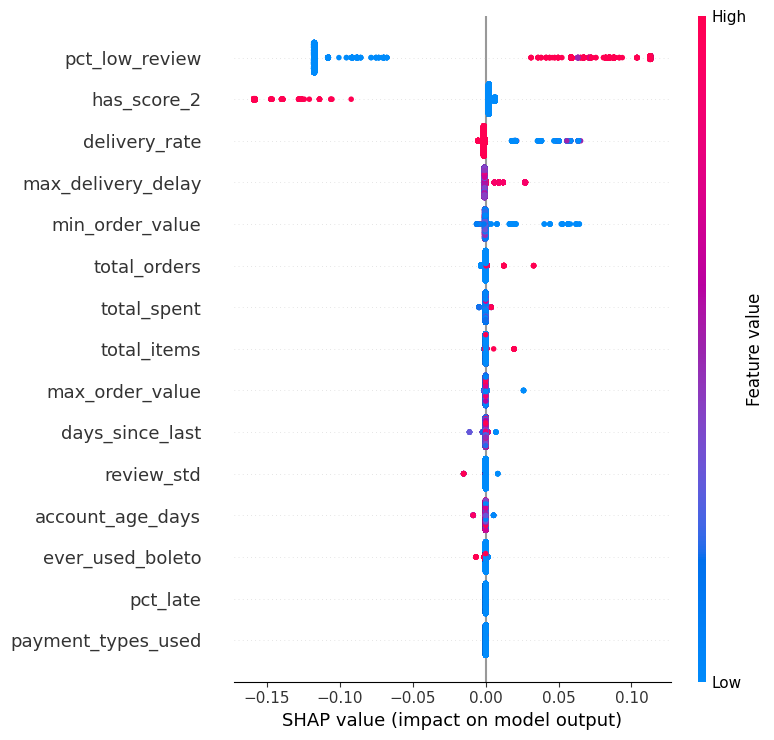


Sample risky customer:
  Probability: 0.53
  Risk score:  52
  Top factors:
    pct_low_review = 1.00 → ↑ increases risk (+0.1130)
    has_score_2 = 0.00 → ↑ increases risk (+0.0065)
    delivery_rate = 1.00 → ↓ decreases risk (-0.0005)
    max_delivery_delay = -21.00 → ↓ decreases risk (-0.0003)
    min_order_value = 39.90 → ↓ decreases risk (-0.0002)

✅ Saved: model_customer_risk.xgb, customer_risk_columns.pkl, customer_risk_threshold.pkl


In [4]:
# ============================================================
# MODEL 1: CUSTOMER RISK — FIXED (Full Olist Dataset)
# ============================================================
!pip install -q pandas numpy scikit-learn xgboost shap matplotlib

import pandas as pd
import numpy as np
import joblib
import shap
import gc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix
)
from xgboost import XGBClassifier

# --- Step 1: Download Olist dataset ---
!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -oq brazilian-ecommerce.zip -d olist_data

orders    = pd.read_csv('olist_data/olist_orders_dataset.csv')
items     = pd.read_csv('olist_data/olist_order_items_dataset.csv')
reviews   = pd.read_csv('olist_data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_data/olist_customers_dataset.csv')
payments  = pd.read_csv('olist_data/olist_order_payments_dataset.csv')

orders = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

print(f"Total orders: {len(orders)}")
print(f"Unique customers: {orders['customer_unique_id'].nunique()}")

# --- Step 2: Build per-ORDER features first ---
# Merge items
order_items = items.groupby('order_id').agg(
    total_items=('order_item_id', 'count'),
    order_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
).reset_index()

orders = orders.merge(order_items, on='order_id', how='left')
orders['order_value'] = orders['order_value'].fillna(0)
orders['freight_value'] = orders['freight_value'].fillna(0)

# Merge reviews
orders = orders.merge(
    reviews[['order_id', 'review_score']].drop_duplicates('order_id'),
    on='order_id', how='left'
)

# Merge payments
pay_agg = payments.groupby('order_id').agg(
    num_payments=('payment_sequential', 'max'),
    num_installments=('payment_installments', 'max'),
    payment_types=('payment_type', 'nunique'),
    used_voucher=('payment_type', lambda x: int('voucher' in x.values)),
    used_boleto=('payment_type', lambda x: int('boleto' in x.values)),
).reset_index()
orders = orders.merge(pay_agg, on='order_id', how='left')

# Delivery delay
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days.fillna(0)
orders['was_late'] = (orders['delivery_delay_days'] > 0).astype(int)

# --- Step 3: Build per-CUSTOMER aggregation ---
# ===============================================
# LABEL DESIGN (avoiding leakage):
#
# Risk signals (used ONLY for label, NOT as features):
#   - Gave review score 1 (very angry customer)
#   - Order was cancelled
#
# Features (used ONLY for training, NOT in label):
#   - Order count, spending patterns, timing
#   - Payment behavior
#   - Delivery experience
#   - Review patterns (2-5 stars only, NOT score=1)
# ===============================================

# -- Label signals --
label_signals = orders.groupby('customer_unique_id').agg(
    has_score_1_review=('review_score', lambda x: int((x == 1).any())),
    has_cancellation=('order_status', lambda x: int((x == 'canceled').any())),
).reset_index()

label_signals['is_risky'] = (
    (label_signals['has_score_1_review'] == 1) |
    (label_signals['has_cancellation'] == 1)
).astype(int)

# -- Features (separate from label) --
max_date = orders['order_purchase_timestamp'].max()

cust = orders.groupby('customer_unique_id').agg(
    # Order patterns
    total_orders=('order_id', 'nunique'),
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max'),

    # Spending
    avg_order_value=('order_value', 'mean'),
    max_order_value=('order_value', 'max'),
    min_order_value=('order_value', 'min'),
    std_order_value=('order_value', 'std'),
    total_spent=('order_value', 'sum'),
    avg_freight=('freight_value', 'mean'),
    total_items=('total_items', 'sum'),

    # Review patterns (2-5 only — 1-star is in the label)
    avg_review=('review_score', lambda x: x[x > 1].mean() if (x > 1).any() else 3.0),
    review_std=('review_score', lambda x: x[x > 1].std() if (x > 1).sum() > 1 else 0.0),
    has_score_2=('review_score', lambda x: int((x == 2).any())),
    has_score_5=('review_score', lambda x: int((x == 5).any())),
    pct_low_review=('review_score', lambda x: (x <= 2).mean()),

    # Delivery
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    max_delivery_delay=('delivery_delay_days', 'max'),
    pct_late=('was_late', 'mean'),

    # Payment behavior
    avg_installments=('num_installments', 'mean'),
    max_installments=('num_installments', 'max'),
    payment_types_used=('payment_types', 'max'),
    ever_used_voucher=('used_voucher', 'max'),
    ever_used_boleto=('used_boleto', 'max'),

    # Status
    delivered_count=('order_status', lambda x: (x == 'delivered').sum()),
).reset_index()

# Derived features
cust['account_age_days'] = (max_date - cust['first_order']).dt.days
cust['days_since_last'] = (max_date - cust['last_order']).dt.days
cust['delivery_rate'] = cust['delivered_count'] / cust['total_orders'].clip(lower=1)
cust['avg_items_per_order'] = cust['total_items'] / cust['total_orders'].clip(lower=1)
cust['value_per_item'] = cust['total_spent'] / cust['total_items'].clip(lower=1)
cust['std_order_value'] = cust['std_order_value'].fillna(0)
cust['review_std'] = cust['review_std'].fillna(0)

# --- Step 4: Merge features + label ---
df = cust.merge(label_signals[['customer_unique_id', 'is_risky']], on='customer_unique_id')

FEATURE_COLS = [
    'total_orders', 'account_age_days', 'days_since_last',
    'avg_order_value', 'max_order_value', 'min_order_value',
    'std_order_value', 'total_spent', 'avg_freight',
    'total_items', 'avg_items_per_order', 'value_per_item',
    'avg_review', 'review_std', 'has_score_2', 'has_score_5', 'pct_low_review',
    'avg_delivery_delay', 'max_delivery_delay', 'pct_late',
    'avg_installments', 'max_installments',
    'payment_types_used', 'ever_used_voucher', 'ever_used_boleto',
    'delivery_rate',
]

df = df[FEATURE_COLS + ['is_risky']].fillna(0).reset_index(drop=True)

print(f"\n{'='*50}")
print(f"Final dataset: {len(df)} customers")
print(f"Risky rate:    {df['is_risky'].mean():.2%}")
print(f"Risky count:   {df['is_risky'].sum()}")
print(f"Normal count:  {(df['is_risky'] == 0).sum()}")
print(f"Features:      {len(FEATURE_COLS)}")
print(f"{'='*50}")
print(df.head())

# --- Step 5: Stratified split ---
X = df[FEATURE_COLS]
y = df['is_risky']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {len(X_train)} (risky {y_train.mean():.2%})")
print(f"Val:   {len(X_val)}  (risky {y_val.mean():.2%})")
print(f"Test:  {len(X_test)}  (risky {y_test.mean():.2%})")

# --- Step 6: Train ---
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight: {pos_weight:.1f}")

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=3.0,
    scale_pos_weight=pos_weight,
    eval_metric='auc',
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# --- Step 7: Evaluate on TEST ---
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

print(f"\n{'='*50}")
print(f"TEST SET RESULTS")
print(f"{'='*50}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

# --- Step 8: Threshold analysis ---
print(f"\n--- Threshold Analysis ---")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

for t in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    preds = (y_prob >= t).astype(int)
    if preds.sum() > 0:
        tp = ((preds == 1) & (y_test.values == 1)).sum()
        fp = ((preds == 1) & (y_test.values == 0)).sum()
        fn = ((preds == 0) & (y_test.values == 1)).sum()
        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * p * r / (p + r + 1e-8)
        print(f"{t:<12.2f} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

print(f"\n✅ Best threshold: {best_threshold:.3f} (F1={f1_scores[best_idx]:.4f})")

y_pred = (y_prob >= best_threshold).astype(int)
print(f"\n--- Classification Report (threshold={best_threshold:.3f}) ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Risky']))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# --- Step 9: Feature importance ---
print(f"\n--- Feature Importance ---")
for feat, imp in sorted(zip(FEATURE_COLS, model.feature_importances_), key=lambda x: -x[1]):
    if imp > 0:
        print(f"  {feat}: {imp:.4f}")

# --- Step 10: SHAP ---
print(f"\n--- SHAP Analysis ---")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.savefig('shap_customer_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample risky customer
risky_idx = y_test[y_test == 1].index
if len(risky_idx) > 0:
    idx = risky_idx[0]
    sample = X_test.loc[[idx]]
    sample_shap = explainer.shap_values(sample)[0]
    prob = model.predict_proba(sample)[0][1]
    print(f"\nSample risky customer:")
    print(f"  Probability: {prob:.2f}")
    print(f"  Risk score:  {int(prob * 100)}")
    print(f"  Top factors:")
    impacts = sorted(zip(FEATURE_COLS, sample_shap), key=lambda x: -abs(x[1]))
    for feat, val in impacts[:5]:
        direction = "↑ increases risk" if val > 0 else "↓ decreases risk"
        print(f"    {feat} = {sample[feat].values[0]:.2f} → {direction} ({val:+.4f})")

# --- Step 11: Save ---
joblib.dump(model, 'model_customer_risk.xgb')
joblib.dump(FEATURE_COLS, 'customer_risk_columns.pkl')
joblib.dump(best_threshold, 'customer_risk_threshold.pkl')
print(f"\n✅ Saved: model_customer_risk.xgb, customer_risk_columns.pkl, customer_risk_threshold.pkl")

train_transaction.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
train_identity.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
Raw dataset: 590540 rows, 434 columns
Fraud rate: 3.50%

Cleaned dataset: 590540 rows, 73 features
Fraud rate: 3.50%

Train: 413378 (fraud 3.52%)
Val:   88581 (fraud 3.43%)
Test:  88581 (fraud 3.48%)
scale_pos_weight: 27.4

--- Finding best scale_pos_weight ---
  weight=5.0    → ROC-AUC=0.8858, PR-AUC=0.4857
  weight=10.0   → ROC-AUC=0.8852, PR-AUC=0.4786
  weight=15.0   → ROC-AUC=0.8851, PR-AUC=0.4785
  weight=20.0   → ROC-AUC=0.8826, PR-AUC=0.4767
  weight=25.0   → ROC-AUC=0.8829, PR-AUC=0.4714
  weight=27.4   → ROC-AUC=0.8811, PR-AUC=0.4661
  weight=30.0   → ROC-AUC=0.8813, PR-AUC=0.4698
  ✅ Best weight: 5
[0]	validation_0-auc:0.80998
[50]	validation_0-auc:0.86555
[100]	validation_0-auc:0.87725
[150]	validation_0-auc:0.88286
[200]	validation_0-auc:0.88671
[250]	validation

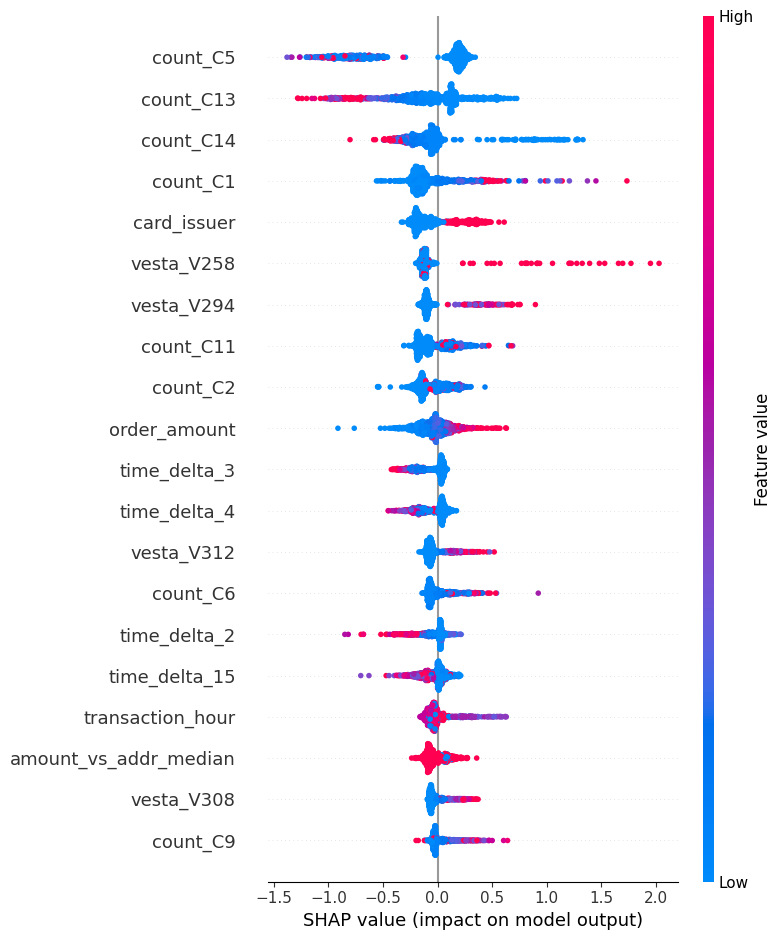

SHAP plot saved as shap_fraud.png

Sample fraudulent transaction (idx=501979):
  Fraud score: 25
  Probability: 0.25
  Top contributing factors:
    + vesta_V258: 0.8938 (value=2.00)
    - count_C1: -0.4420 (value=2.00)
    + card_issuer: 0.3102 (value=1.00)
    - count_C11: -0.2305 (value=1.00)
    + count_C5: 0.2163 (value=0.00)
    - count_C14: -0.1915 (value=1.00)

✅ Saved: model_fraud.xgb, fraud_columns.pkl, fraud_threshold.pkl


In [1]:
# ============================================================
# MODEL 2: FRAUD DETECTION — IMPROVED
# ============================================================
!pip install -q pandas numpy scikit-learn xgboost shap matplotlib

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix
)
from xgboost import XGBClassifier

# --- Step 1: Download IEEE-CIS dataset ---
!kaggle competitions download -c ieee-fraud-detection -f train_transaction.csv
!kaggle competitions download -c ieee-fraud-detection -f train_identity.csv
!unzip -oq train_transaction.csv.zip
!unzip -oq train_identity.csv.zip

txn = pd.read_csv('train_transaction.csv')
identity = pd.read_csv('train_identity.csv')

# Merge transaction + identity (identity has device info)
raw = txn.merge(identity, on='TransactionID', how='left')
print(f"Raw dataset: {raw.shape[0]} rows, {raw.shape[1]} columns")
print(f"Fraud rate: {raw['isFraud'].mean():.2%}")

# --- Step 2: Feature engineering ---
df = pd.DataFrame()

# === Core transaction features ===
df['order_amount']      = raw['TransactionAmt']
df['log_amount']        = np.log1p(raw['TransactionAmt'])
df['avs_match']         = (raw['addr1'].notna() & raw['addr2'].notna()).astype(int)
df['cvv_match']         = (raw['card5'].notna()).astype(int)
df['three_ds']          = (raw['V96'].notna()).astype(int)
df['account_age_days']  = raw['D1'].fillna(-1).astype(int)
df['shipping_mismatch'] = (raw['addr1'].fillna(0) != raw['addr2'].fillna(0)).astype(int)

# === Transaction velocity features (D columns = time deltas) ===
df['time_delta_1']  = raw['D1'].fillna(-1)   # days since previous txn
df['time_delta_2']  = raw['D2'].fillna(-1)
df['time_delta_3']  = raw['D3'].fillna(-1)   # days since previous addr usage
df['time_delta_4']  = raw['D4'].fillna(-1)
df['time_delta_10'] = raw['D10'].fillna(-1)  # days since account creation
df['time_delta_15'] = raw['D15'].fillna(-1)

# Transaction hour/day features
df['transaction_hour'] = raw['TransactionDT'] % 86400 // 3600
df['is_night']         = ((df['transaction_hour'] >= 0) & (df['transaction_hour'] <= 6)).astype(int)
df['is_weekend']       = ((raw['TransactionDT'] // 86400) % 7 >= 5).astype(int)

# === Card features (payment method diversity proxy) ===
df['card_type']   = raw['card4'].map({'visa': 0, 'mastercard': 1, 'american express': 2, 'discover': 3}).fillna(-1)
df['card_issuer'] = raw['card6'].map({'debit': 0, 'credit': 1, 'charge card': 2, 'debit or credit': 3}).fillna(-1)

# === Device features ===
df['new_device']     = raw['DeviceType'].isna().astype(int)
df['device_type']    = raw['DeviceType'].map({'desktop': 0, 'mobile': 1}).fillna(-1)
df['device_info_na'] = raw['DeviceInfo'].isna().astype(int)

# === Behavioral Vesta features (V columns — aggregated risk signals) ===
# Pick the most informative V columns (based on typical analysis)
v_cols = ['V1', 'V2', 'V3', 'V4', 'V5', 'V12', 'V13', 'V14', 'V15',
          'V54', 'V55', 'V56', 'V75', 'V76', 'V78', 'V82', 'V83',
          'V87', 'V258', 'V261', 'V264', 'V279', 'V280', 'V283',
          'V285', 'V294', 'V306', 'V307', 'V308', 'V310', 'V312', 'V313', 'V314', 'V315']
for col in v_cols:
    if col in raw.columns:
        df[f'vesta_{col}'] = raw[col].fillna(-999)

# === Email domain features ===
df['email_match'] = (raw['P_emaildomain'] == raw['R_emaildomain']).astype(int)
df['email_missing'] = (raw['P_emaildomain'].isna() | raw['R_emaildomain'].isna()).astype(int)

# === Amount statistics ===
# Amount relative to card median
card_amt_median = raw.groupby('card1')['TransactionAmt'].transform('median')
df['amount_vs_card_median'] = raw['TransactionAmt'] / card_amt_median.clip(lower=1)

# Amount relative to address median
addr_amt_median = raw.groupby('addr1')['TransactionAmt'].transform('median')
df['amount_vs_addr_median'] = raw['TransactionAmt'] / addr_amt_median.clip(lower=1)

# === C columns (counting features — velocity) ===
for c in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']:
    if c in raw.columns:
        df[f'count_{c}'] = raw[c].fillna(0)

# === Target ===
df['is_fraud'] = raw['isFraud']

# Drop rows with too many NaNs
df = df.dropna(thresh=int(len(df.columns) * 0.5)).reset_index(drop=True)
df = df.fillna(-999)  # fill remaining NaN for XGBoost

FEATURE_COLS = [c for c in df.columns if c != 'is_fraud']
print(f"\nCleaned dataset: {len(df)} rows, {len(FEATURE_COLS)} features")
print(f"Fraud rate: {df['is_fraud'].mean():.2%}")

# --- Step 3: Time-based split ---
# TransactionDT is relative time — use it for chronological ordering
# Data is already sorted by TransactionDT in the original file
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train = df.iloc[:train_end][FEATURE_COLS]
y_train = df.iloc[:train_end]['is_fraud']
X_val   = df.iloc[train_end:val_end][FEATURE_COLS]
y_val   = df.iloc[train_end:val_end]['is_fraud']
X_test  = df.iloc[val_end:][FEATURE_COLS]
y_test  = df.iloc[val_end:]['is_fraud']

print(f"\nTrain: {len(X_train)} (fraud {y_train.mean():.2%})")
print(f"Val:   {len(X_val)} (fraud {y_val.mean():.2%})")
print(f"Test:  {len(X_test)} (fraud {y_test.mean():.2%})")

# --- Step 4: Train with tuned hyperparameters ---
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight: {pos_weight:.1f}")

# Test multiple scale_pos_weight values
print("\n--- Finding best scale_pos_weight ---")
best_auc = 0
best_weight = pos_weight
for w in [5, 10, 15, 20, 25, pos_weight, 30]:
    tmp_model = XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        scale_pos_weight=w, eval_metric='auc', n_jobs=-1, random_state=42,
    )
    tmp_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    auc = roc_auc_score(y_val, tmp_model.predict_proba(X_val)[:, 1])
    pr_auc = average_precision_score(y_val, tmp_model.predict_proba(X_val)[:, 1])
    print(f"  weight={w:<6.1f} → ROC-AUC={auc:.4f}, PR-AUC={pr_auc:.4f}")
    if auc > best_auc:
        best_auc = auc
        best_weight = w

print(f"  ✅ Best weight: {best_weight}")

# Final training with best weight
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=2.0,
    scale_pos_weight=best_weight,
    eval_metric='auc',
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# --- Step 5: Evaluate on TEST set ---
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

print(f"\n{'='*50}")
print(f"TEST SET RESULTS")
print(f"{'='*50}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

# --- Step 6: Threshold optimization ---
print(f"\n--- Threshold Analysis ---")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'FPR':<12}")
print("-" * 60)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

for t in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    preds = (y_prob >= t).astype(int)
    if preds.sum() > 0:
        tp = ((preds == 1) & (y_test.values == 1)).sum()
        fp = ((preds == 1) & (y_test.values == 0)).sum()
        fn = ((preds == 0) & (y_test.values == 1)).sum()
        tn = ((preds == 0) & (y_test.values == 0)).sum()
        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * p * r / (p + r + 1e-8)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        print(f"{t:<12.2f} {p:<12.4f} {r:<12.4f} {f:<12.4f} {fpr:<12.4f}")

print(f"\n✅ Best threshold: {best_threshold:.3f} (F1={f1_scores[best_idx]:.4f})")

# Risk bands (for production)
print(f"\n--- Recommended Risk Bands ---")
print(f"  LOW RISK:    probability < 0.30")
print(f"  INVESTIGATE: probability 0.30 - 0.70")
print(f"  HIGH RISK:   probability > 0.70")

y_pred = (y_prob >= best_threshold).astype(int)
print(f"\n--- Classification Report (threshold={best_threshold:.3f}) ---")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# --- Step 7: Feature importance (top 20) ---
print(f"\n--- Top 20 Feature Importance ---")
importances = sorted(zip(FEATURE_COLS, model.feature_importances_), key=lambda x: -x[1])
for feat, imp in importances[:20]:
    print(f"  {feat}: {imp:.4f}")

# --- Step 8: SHAP explanations ---
print(f"\n--- SHAP Analysis ---")
# Use a sample for speed
X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.tight_layout()
plt.savefig('shap_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved as shap_fraud.png")

# Single transaction explanation
fraud_indices = y_test[y_test == 1].index.tolist()
if fraud_indices:
    sample_idx = fraud_indices[0]
    sample = X_test.loc[[sample_idx]]
    sample_shap = explainer.shap_values(sample)[0]
    prob = model.predict_proba(sample)[0][1]
    score = int(prob * 100)

    print(f"\nSample fraudulent transaction (idx={sample_idx}):")
    print(f"  Fraud score: {score}")
    print(f"  Probability: {prob:.2f}")
    print(f"  Top contributing factors:")
    feature_impacts = sorted(zip(FEATURE_COLS, sample_shap), key=lambda x: -abs(x[1]))
    for feat, val in feature_impacts[:6]:
        direction = "+" if val > 0 else "-"
        print(f"    {direction} {feat}: {val:.4f} (value={sample[feat].values[0]:.2f})")

# --- Step 9: Save ---
joblib.dump(model, 'model_fraud.xgb')
joblib.dump(FEATURE_COLS, 'fraud_columns.pkl')
joblib.dump(best_threshold, 'fraud_threshold.pkl')
print(f"\n✅ Saved: model_fraud.xgb, fraud_columns.pkl, fraud_threshold.pkl")

In [7]:
# ============================================================
# MODEL 3: EVIDENCE COMPLETENESS — UPDATED RULES
# ============================================================
import json

EVIDENCE_RULES = {
    "Item Not Received": {
        "required": [
            {"name": "Tracking Information",       "weight": 30},
            {"name": "Delivery Status",            "weight": 30},
            {"name": "Fulfillment Record",         "weight": 20},
            {"name": "Shipping Address",           "weight": 10},
            {"name": "Order Record",               "weight": 10},
        ]
    },
    "Unauthorized Transaction": {
        "required": [
            {"name": "Payment Transaction",        "weight": 25},
            {"name": "Payment Gateway",            "weight": 15},
            {"name": "Fraud/Risk Assessment",      "weight": 25},
            {"name": "Billing Address",            "weight": 15},
            {"name": "Order Customer",             "weight": 20},
        ]
    },
    "Product Not As Described": {
        "required": [
            {"name": "Product Details",            "weight": 30},
            {"name": "Order Line Items",           "weight": 25},
            {"name": "Customer Order",             "weight": 15},
            {"name": "Return Information",         "weight": 15},
            {"name": "Customer/Order Notes",       "weight": 15},
        ]
    },
    "Duplicate Charge": {
        "required": [
            {"name": "Payment Transactions",       "weight": 35},
            {"name": "Order Financial Status",     "weight": 20},
            {"name": "Transaction IDs",            "weight": 25},
            {"name": "Refund Records",             "weight": 20},
        ]
    },
    "Item Damaged": {
        "required": [
            {"name": "Fulfillment Record",         "weight": 20},
            {"name": "Tracking Information",       "weight": 20},
            {"name": "Shipment Status",            "weight": 20},
            {"name": "Return Information",         "weight": 25},
            {"name": "Order Line Items",           "weight": 15},
        ]
    },
    "Wrong Item Received": {
        "required": [
            {"name": "Order Line Items",           "weight": 30},
            {"name": "Product Details",            "weight": 25},
            {"name": "Fulfillment Record",         "weight": 20},
            {"name": "Tracking Information",       "weight": 10},
            {"name": "Return Information",         "weight": 15},
        ]
    },
    "Missing Item": {
        "required": [
            {"name": "Order Line Items",           "weight": 30},
            {"name": "Fulfillment Record",         "weight": 25},
            {"name": "Fulfillment Line Items",     "weight": 25},
            {"name": "Product Details",            "weight": 10},
            {"name": "Return Information",         "weight": 10},
        ]
    },
}


def evaluate_evidence(dispute_type: str, available_evidence: list) -> dict:
    rules = EVIDENCE_RULES.get(dispute_type)
    if not rules:
        return {"error": f"Unknown dispute type: {dispute_type}. Valid: {list(EVIDENCE_RULES.keys())}"}

    total_weight = sum(e["weight"] for e in rules["required"])
    available_set = set(available_evidence)

    matched_weight = 0
    available = []
    missing = []

    for item in rules["required"]:
        if item["name"] in available_set:
            matched_weight += item["weight"]
            available.append(item["name"])
        else:
            missing.append(item)

    score = int((matched_weight / total_weight) * 100)
    strength = "Strong" if score >= 80 else ("Medium" if score >= 50 else "Weak")

    missing_sorted = sorted(missing, key=lambda x: -x["weight"])
    highest_impact = [missing_sorted[0]["name"]] if missing_sorted else []

    return {
        "evidence_score": score,
        "evidence_strength": strength,
        "available_evidence": available,
        "missing_evidence": [m["name"] for m in missing_sorted],
        "highest_impact_missing": highest_impact,
    }


# --- Test all dispute types ---
tests = [
    ("Item Not Received",       ["Tracking Information", "Order Record"]),
    ("Unauthorized Transaction", ["Payment Transaction", "Fraud/Risk Assessment", "Order Customer"]),
    ("Product Not As Described", ["Product Details", "Order Line Items"]),
    ("Duplicate Charge",         ["Payment Transactions", "Transaction IDs", "Refund Records"]),
    ("Item Damaged",             ["Fulfillment Record", "Tracking Information"]),
    ("Wrong Item Received",      ["Order Line Items", "Product Details", "Fulfillment Record"]),
    ("Missing Item",             ["Order Line Items"]),
]

for dtype, evidence in tests:
    result = evaluate_evidence(dtype, evidence)
    print(f"\n{'='*50}")
    print(f"Dispute: {dtype}")
    print(f"Score: {result['evidence_score']}% ({result['evidence_strength']})")
    print(f"Available: {result['available_evidence']}")
    print(f"Missing:   {result['missing_evidence']}")
    print(f"Highest impact missing: {result['highest_impact_missing']}")

# Save
with open("evidence_rules.json", "w") as f:
    json.dump(EVIDENCE_RULES, f, indent=2)
print(f"\n✅ Saved: evidence_rules.json")


Dispute: Item Not Received
Score: 40% (Weak)
Available: ['Tracking Information', 'Order Record']
Missing:   ['Delivery Status', 'Fulfillment Record', 'Shipping Address']
Highest impact missing: ['Delivery Status']

Dispute: Unauthorized Transaction
Score: 70% (Medium)
Available: ['Payment Transaction', 'Fraud/Risk Assessment', 'Order Customer']
Missing:   ['Payment Gateway', 'Billing Address']
Highest impact missing: ['Payment Gateway']

Dispute: Product Not As Described
Score: 55% (Medium)
Available: ['Product Details', 'Order Line Items']
Missing:   ['Customer Order', 'Return Information', 'Customer/Order Notes']
Highest impact missing: ['Customer Order']

Dispute: Duplicate Charge
Score: 80% (Strong)
Available: ['Payment Transactions', 'Transaction IDs', 'Refund Records']
Missing:   ['Order Financial Status']
Highest impact missing: ['Order Financial Status']

Dispute: Item Damaged
Score: 40% (Weak)
Available: ['Fulfillment Record', 'Tracking Information']
Missing:   ['Return Infor

In [2]:
# ============================================================
# MODEL 4: ISOLATION FOREST ANOMALY — MEMORY-SAFE FOR COLAB
# ============================================================
!pip install -q pandas numpy scikit-learn

import pandas as pd
import numpy as np
import joblib
import gc
from sklearn.ensemble import IsolationForest

# --- Step 1: Load ONLY the columns we need (saves ~60% RAM) ---
USE_COLS = [
    'TransactionAmt', 'addr1', 'addr2', 'card4', 'card5', 'card6',
    'D1', 'D3', 'D10', 'D15', 'V96', 'TransactionDT',
    'C1', 'C2', 'C3', 'C5', 'C6', 'C13', 'C14',
]

raw = pd.read_csv('train_transaction.csv', usecols=USE_COLS)
print(f"Loaded {len(raw)} rows, {raw.shape[1]} columns")
print(f"Memory: {raw.memory_usage(deep=True).sum() / 1e6:.0f} MB")

# --- Step 2: Build features ---
df = pd.DataFrame()
df['order_amount']      = raw['TransactionAmt'].astype(np.float32)
df['log_amount']        = np.log1p(raw['TransactionAmt']).astype(np.float32)
df['avs_match']         = (raw['addr1'].notna() & raw['addr2'].notna()).astype(np.int8)
df['cvv_match']         = (raw['card5'].notna()).astype(np.int8)
df['three_ds']          = (raw['V96'].notna()).astype(np.int8)
df['account_age_days']  = raw['D1'].fillna(-1).astype(np.float32)
df['shipping_mismatch'] = (raw['addr1'].fillna(0) != raw['addr2'].fillna(0)).astype(np.int8)
df['time_delta_1']      = raw['D1'].fillna(-1).astype(np.float32)
df['time_delta_3']      = raw['D3'].fillna(-1).astype(np.float32)
df['time_delta_10']     = raw['D10'].fillna(-1).astype(np.float32)
df['time_delta_15']     = raw['D15'].fillna(-1).astype(np.float32)
df['transaction_hour']  = (raw['TransactionDT'] % 86400 // 3600).astype(np.int8)
df['is_night']          = ((df['transaction_hour'] >= 0) & (df['transaction_hour'] <= 6)).astype(np.int8)

for c in ['C1', 'C2', 'C3', 'C5', 'C6', 'C13', 'C14']:
    df[f'count_{c}'] = raw[c].fillna(0).astype(np.float32)

# Free raw data immediately
del raw
gc.collect()

df = df.fillna(-999)
FEATURE_COLS = list(df.columns)
print(f"\nFeature matrix: {len(df)} rows × {len(FEATURE_COLS)} cols")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

# --- Step 3: SAMPLE for training (IsolationForest doesn't need all rows) ---
TRAIN_SIZE = 50_000  # 50K rows is plenty for IsolationForest
train_sample = df.sample(n=TRAIN_SIZE, random_state=42)
print(f"\nTraining on {TRAIN_SIZE} sampled rows (out of {len(df)})")

# --- Step 4: Train ---
iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples=min(10000, TRAIN_SIZE),
    max_features=0.8,
    random_state=42,
    n_jobs=-1,
)
iso.fit(train_sample)
print("✅ IsolationForest trained")

# Free training sample
del train_sample
gc.collect()

# --- Step 5: Compute normalization bounds on a SAMPLE (not full dataset) ---
BOUNDS_SAMPLE = 30_000
bounds_sample = df.sample(n=BOUNDS_SAMPLE, random_state=99)
raw_scores = iso.decision_function(bounds_sample)

SCORE_MIN = float(raw_scores.min())
SCORE_MAX = float(raw_scores.max())
print(f"Score bounds: min={SCORE_MIN:.4f}, max={SCORE_MAX:.4f}")

# Show distribution on the sample
anomaly_scores = np.clip(
    ((SCORE_MAX - raw_scores) / (SCORE_MAX - SCORE_MIN) * 100).astype(int),
    0, 100
)

print(f"\nAnomaly score distribution ({BOUNDS_SAMPLE} sample):")
print(f"  Mean:   {anomaly_scores.mean():.1f}")
print(f"  Median: {np.median(anomaly_scores):.1f}")
print(f"  P95:    {np.percentile(anomaly_scores, 95):.1f}")
print(f"  P99:    {np.percentile(anomaly_scores, 99):.1f}")

for band, lo, hi in [("Typical (0-40)", 0, 40), ("Unusual (40-70)", 40, 70),
                       ("Very Unusual (70-90)", 70, 90), ("Extreme (90-100)", 90, 101)]:
    count = ((anomaly_scores >= lo) & (anomaly_scores < hi)).sum()
    print(f"  {band}: {count} ({count/len(anomaly_scores)*100:.1f}%)")

del bounds_sample, raw_scores, anomaly_scores
gc.collect()

# --- Step 6: Save percentile stats for factor explanation ---
# Compute percentiles on a small sample (for explain_anomaly later)
STATS_SAMPLE = 20_000
stats_sample = df.sample(n=STATS_SAMPLE, random_state=77)
percentile_stats = {}
for col in FEATURE_COLS:
    percentile_stats[col] = {
        'p3':  float(np.percentile(stats_sample[col], 3)),
        'p97': float(np.percentile(stats_sample[col], 97)),
        'median': float(stats_sample[col].median()),
    }

del stats_sample, df
gc.collect()

# --- Step 7: Explain anomaly helper ---
def explain_anomaly(sample_dict, stats):
    factors = []
    for col, val in sample_dict.items():
        if col not in stats:
            continue
        s = stats[col]
        if val > s['p97']:
            factors.append(f"{col} is extremely high ({val:.1f} vs median {s['median']:.1f})")
        elif val < s['p3']:
            factors.append(f"{col} is extremely low ({val:.1f} vs median {s['median']:.1f})")
    return factors[:5]

# --- Step 8: Test single prediction ---
sample = {
    'order_amount': 9500, 'log_amount': np.log1p(9500),
    'avs_match': 0, 'cvv_match': 1, 'three_ds': 0,
    'account_age_days': 2, 'shipping_mismatch': 1,
    'time_delta_1': 0, 'time_delta_3': 0,
    'time_delta_10': 2, 'time_delta_15': 2,
    'transaction_hour': 3, 'is_night': 1,
    'count_C1': 50, 'count_C2': 40, 'count_C3': 0,
    'count_C5': 0, 'count_C6': 30, 'count_C13': 60, 'count_C14': 30,
}
sample_df = pd.DataFrame([sample])

raw_s = iso.decision_function(sample_df)[0]
score = int(np.clip((SCORE_MAX - raw_s) / (SCORE_MAX - SCORE_MIN) * 100, 0, 100))
level = "Very Unusual" if score > 80 else ("Unusual" if score > 50 else "Typical")
factors = explain_anomaly(sample, percentile_stats)

print(f"\n{'='*50}")
print(f"Sample transaction:")
print(f"  anomaly_score: {score}")
print(f"  anomaly_level: {level}")
print(f"  anomaly_factors:")
for f in factors:
    print(f"    • {f}")

# --- Step 9: Save ---
joblib.dump(iso, 'model_isolation_forest.model')
joblib.dump({'min': SCORE_MIN, 'max': SCORE_MAX}, 'anomaly_bounds.pkl')
joblib.dump(FEATURE_COLS, 'anomaly_columns.pkl')
joblib.dump(percentile_stats, 'anomaly_percentile_stats.pkl')

print(f"\n✅ Saved:")
print(f"  model_isolation_forest.model")
print(f"  anomaly_bounds.pkl")
print(f"  anomaly_columns.pkl")
print(f"  anomaly_percentile_stats.pkl")

Loaded 590540 rows, 19 columns
Memory: 145 MB

Feature matrix: 590540 rows × 20 cols
Memory: 37 MB

Training on 50000 sampled rows (out of 590540)
✅ IsolationForest trained
Score bounds: min=-0.2929, max=0.1561

Anomaly score distribution (30000 sample):
  Mean:   11.2
  Median: 9.0
  P95:    35.0
  P99:    54.0
  Typical (0-40): 28922 (96.4%)
  Unusual (40-70): 1006 (3.4%)
  Very Unusual (70-90): 59 (0.2%)
  Extreme (90-100): 13 (0.0%)

Sample transaction:
  anomaly_score: 79
  anomaly_level: Unusual
  anomaly_factors:
    • order_amount is extremely high (9500.0 vs median 68.9)
    • log_amount is extremely high (9.2 vs median 4.2)
    • three_ds is extremely low (0.0 vs median 1.0)

✅ Saved:
  model_isolation_forest.model
  anomaly_bounds.pkl
  anomaly_columns.pkl
  anomaly_percentile_stats.pkl


<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

## Google Colab is available in VS Code!
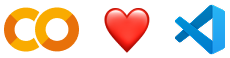

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  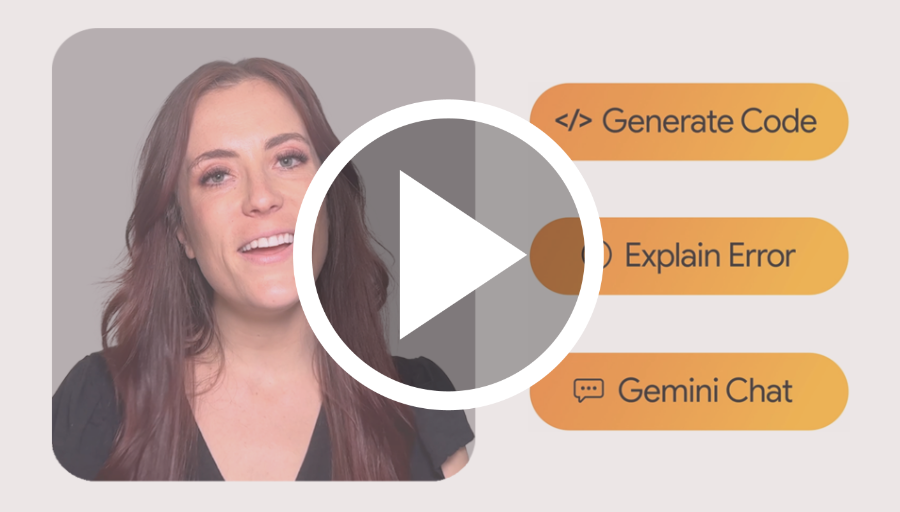
  </a>
</center>

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

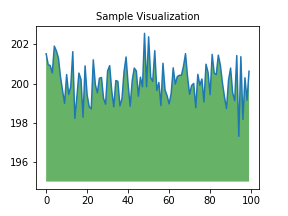

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
